In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
import json
import copy
import os
from scipy import signal

# resave file 

In [2]:
params = {}
# filename = r"..\data\tests\test_008_piu.h5"
filename = r"D:\2025 - TEP\data - raw\tests\36 test Anatoly New rest\06_AM_M1_motor_imagery.hdf5"

with h5py.File(filename, "r") as h5f:
    for key in h5f['eeg/streamInfo'].keys():
        if key in ['temporary_as_json']:
            params[key] = np.array([json.loads(h5f['eeg/streamInfo'][key].asstr()[:][0])], dtype=object)
        elif key in ['name', 'type', 'uid']:
            params[key] = h5f['eeg/streamInfo'][key].asstr()[()]
        elif key in ['channels', 'samplingRate']:
            params[key] = h5f['eeg/streamInfo'][key][:]
        elif key == 'connections':
            params[key] = h5f['eeg/streamInfo'][key].asstr()[:]

    blocks = h5f['eeg/blocks'][:]
    data = h5f['eeg/data'][:]

Text(0.5, 0, 'idx')

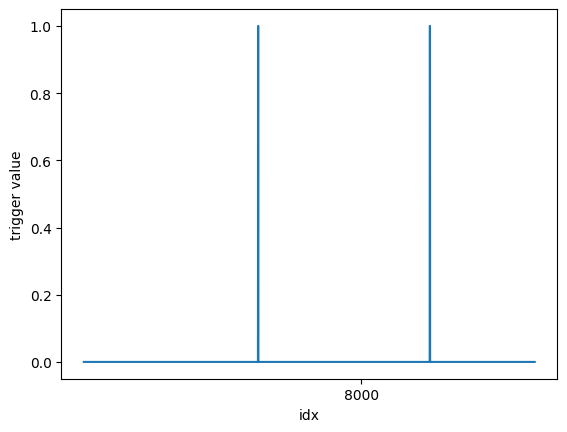

In [3]:
def redefine_trigger(trigger, bit):
    ttl = np.array(trigger, dtype=np.uint8)
    return ((ttl>>bit) & 0b1).astype(int)

# select desired segment
start, end = 8000, 21000
time_end = int(end * 25000 / 1000)
time_start = int(start * 25000 / 1000)
trigger = redefine_trigger(data[:, -1], 0)
plt.plot(trigger[time_start:time_end]);
step = 25000
plt.xticks(np.arange(time_start, time_end, step *25000/1000), np.arange(start, end, step))
plt.ylabel('trigger value')
plt.xlabel('idx')

In [4]:
def cut_segment(start, end, blocks, data):
    """
    params:
        - start : время начальной точки в мс
        - end : время конечной точки в мс
    """
    
    def find_nearest_block(ts, time_moment):
        t_first = ts[0]
        for i, t in enumerate(ts):
            if t > t_first + time_moment*1E6:
                return i
        return None

    start_idx = find_nearest_block(blocks["created"], start)
    end_idx = find_nearest_block(blocks["created"], end)
    if start_idx is None or end_idx is None:
        print(f"start time index: {start_idx}; end time index: {end_idx}. Sth is wrong here.")
        return None, None
    
    def calculate_data_idx(block_sizes, block_idx):
        data_idx = 0
        for i in range(block_idx):
            data_idx += block_sizes[i]
        return data_idx
    
    data_start_idx = calculate_data_idx(blocks["samples"], start_idx)
    data_end_idx = calculate_data_idx(blocks["samples"], end_idx)

    # cut segment of data
    data2safe = data[data_start_idx:data_end_idx]
    blocks2safe = blocks[start_idx:end_idx]
    return data2safe, blocks2safe

data2safe, blocks2safe = cut_segment(start, end, blocks, data)
data2safe.shape, blocks2safe.shape

((325360, 67), (166,))

In [6]:
filename_output = r"D:\Resonance\dist_2025\mulines\src\mulines\data\record_short.h5"
string_dt = h5py.string_dtype(encoding='utf-8')
with h5py.File(filename_output, "w") as h5f:
    eeg = h5f.create_group('eeg')
    streamInfo = eeg.create_group('streamInfo')
    for key, value in params.items():
        if key == 'temporary_as_json': 
            data = np.array([json.dumps(value[0])], dtype=object)
            streamInfo.create_dataset(key, data=data, dtype=string_dt)
        elif key == 'connections':
            data = value.tolist()
            streamInfo.create_dataset(key, data=data, dtype=string_dt)
        else:
            streamInfo.create_dataset(key, data=value)
    dtype = [('created', '<u8'), ('received', '<u8'), ('samples', '<u4')]
    data_np = np.array(list(blocks2safe), dtype=dtype)
    eeg.create_dataset('blocks', data=data_np, shape=data_np.shape, dtype=dtype)
    eeg.create_dataset('data', data=data2safe)

In [ ]:
filename = r"D:\Resonance\distro-dual\msvc\mulines\src\mulines\data\whole_dataset_ES.h5"
with h5py.File(filename, 'r') as h5f:
    epochs = h5f['epochs'][:]
    raw_signal = h5f["raw_signal"][:]
    interp_signal = h5f["interp_signal"][:]
    # notch_signal = h5f['notch_filt'][:]
n_events = 34
n_samples = 2000

In [ ]:
plt.plot(epochs);

In [ ]:
filename = r"D:\Resonance\distro-dual\msvc\bin\04_ES_SMA_qp_0_bad.hdf5"
with h5py.File(filename, 'r') as h5f:
    blocks = h5f['eeg/blocks'][:]
block_signal = np.zeros(len(raw_signal))
block_signal[np.cumsum(blocks["samples"])-1] = 1

In [ ]:
shift = 2000

In [ ]:
raw_signal.shape, interp_signal.shape, notch_signal.shape, raw_signal.shape[0] - interp_signal.shape[0]

In [ ]:
plt.figure(figsize=(10, 2))
plt.plot(raw_signal[:, 10])
plt.plot(interp_signal[:, 10]);

In [ ]:
start_idx = np.where(interp_signal[:, 10]>0.2)[0][0]-1000
end_idx = np.where(interp_signal[:, 10]>0.2)[0][0]+100
plt.plot(raw_signal[start_idx-shift:end_idx, 10])
plt.plot(interp_signal[start_idx:end_idx, 10]);
plt.plot(block_signal[start_idx-shift:end_idx]);

In [ ]:
start_idx

In [ ]:
filename = r"C:\Users\Anatoly\Downloads\im1.edf"
import numpy as np
import pyedflib

# Самый простой рабочий код
f = pyedflib.EdfReader(filename)
n = f.signals_in_file
print(f"В файле {n} каналов")
data = f.readSignal(0)  # читаем первый канал
print(f"Данные первого канала: {len(data)} точек")
f.close()

In [ ]:
len(data)

In [ ]:

plt.plot(block_signal);